In [3]:
# Cell 1 — Imports & config



import os, re, json, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy import signal, stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from joblib import Parallel, delayed

sys.path.insert(0, str(Path.cwd().parent.parent))
warnings.filterwarnings("ignore")
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({"figure.dpi": 110})
pd.set_option("display.width", 200, "display.max_columns", 80)

# ------------------------------------------------------------------ CONFIG
ROOT = Path("../data_paderborn")                       # folder with K001, KA01, ... KB27
OUT  = Path("../data_paderborn/eda_out"); OUT.mkdir(parents=True, exist_ok=True)
FIG  = OUT / "figs";                       FIG.mkdir(parents=True, exist_ok=True)

FS_FAST, FS_SLOW = 64_000, 4_000     # documented rasters — used for PSD axes only
DUR_S            = 4.0               # nominal record length — informational only

CH_MAIN = ["vibration_1", "phase_current_1", "phase_current_2"]   # 64 kHz
CH_SLOW = ["force", "speed", "torque"]                            # 4 kHz
CH_AUX  = ["temp_2_bearing_module"]                               # ~1 Hz
ALL_CH  = CH_MAIN + CH_SLOW + CH_AUX

PROBE_PER_BEARING  = 3      # files/bearing for the structural census (Cell 5)
SAMPLE_PER_BEARING = 8      # files/bearing for the feature pass; None = all 2560
N_JOBS = 8
SEED   = 42
rng = np.random.default_rng(SEED)

print("root exists:", ROOT.exists(), "| bearing folders:", len(list(ROOT.glob("K*"))))

root exists: True | bearing folders: 32


In [4]:
# Cell 2 — Domain metadata

DAMAGE_CATALOG = {  # code: (component, damage_origin, method/mode, severity)
 **{k: ("healthy", "none", "-", 0) for k in ["K001","K002","K003","K004","K005","K006"]},
 # ---- artificial (12)
 "KA01": ("OR","artificial","EDM",1),        "KA03": ("OR","artificial","engraver",2),
 "KA05": ("OR","artificial","engraver",1),   "KA06": ("OR","artificial","engraver",2),
 "KA07": ("OR","artificial","drilling",1),   "KA08": ("OR","artificial","drilling",2),
 "KA09": ("OR","artificial","drilling",2),
 "KI01": ("IR","artificial","EDM",1),        "KI03": ("IR","artificial","engraver",1),
 "KI05": ("IR","artificial","engraver",1),   "KI07": ("IR","artificial","engraver",2),
 "KI08": ("IR","artificial","engraver",2),
 # ---- real, accelerated lifetime tests (14)
 "KA04": ("OR","real","pitting",1),          "KA15": ("OR","real","indentation",1),
 "KA16": ("OR","real","pitting",2),          "KA22": ("OR","real","pitting",1),
 "KA30": ("OR","real","indentation",1),
 "KB23": ("IR+OR","real","pitting",2),       "KB24": ("IR+OR","real","distributed",3),
 "KB27": ("IR+OR","real","indentation",1),
 "KI04": ("IR","real","pitting",1),          "KI14": ("IR","real","pitting",1),
 "KI16": ("IR","real","pitting",3),          "KI17": ("IR","real","pitting",1),
 "KI18": ("IR","real","pitting",2),          "KI21": ("IR","real","pitting",1),
}
assert len(DAMAGE_CATALOG) == 32

OP_CONDITIONS = {          # code -> (rpm, load torque [Nm], radial force [N])
 "N09_M07_F10": (900, 0.7, 1000),
 "N15_M07_F10": (1500, 0.7, 1000),
 "N15_M01_F10": (1500, 0.1, 1000),
 "N15_M07_F04": (1500, 0.7,  400),
}

# nominal fault-frequency ratios for a 6203 deep-groove ball bearing (x shaft freq)
BEARING_6203 = {"FTF": 0.3817, "BPFO": 3.0530, "BPFI": 4.9469, "BSF": 1.9947}

def fault_freqs(rpm):
    fr = rpm / 60.0
    return {"fr": fr, **{k: v * fr for k, v in BEARING_6203.items()}}

display(pd.DataFrame(DAMAGE_CATALOG, index=["component","origin","mode","severity"]).T.head(10))
display(pd.DataFrame(OP_CONDITIONS, index=["rpm","torque_Nm","force_N"]).T)

,component,origin,mode,severity
K001,healthy,none,-,0
K002,healthy,none,-,0
K003,healthy,none,-,0
K004,healthy,none,-,0
K005,healthy,none,-,0
K006,healthy,none,-,0
KA01,OR,artificial,EDM,1
KA03,OR,artificial,engraver,2
KA05,OR,artificial,engraver,1
KA06,OR,artificial,engraver,2


,rpm,torque_Nm,force_N
N09_M07_F10,900.0,0.7,1000.0
N15_M07_F10,1500.0,0.7,1000.0
N15_M01_F10,1500.0,0.1,1000.0
N15_M07_F04,1500.0,0.7,400.0


In [5]:
# Cell 3 — File inventory + integrity check


FNAME_RE = re.compile(r"^N(?P<n>\d+)_M(?P<m>\d+)_F(?P<f>\d+)_(?P<bearing>K[A-Z]?\d+)_(?P<trial>\d+)$",
                      re.I)

rows, unparsed = [], []
for mat in sorted(ROOT.rglob("*.mat")):
    m = FNAME_RE.match(mat.stem)
    if not m:
        unparsed.append(mat.name); continue
    d = m.groupdict()
    cond = f"N{int(d['n']):02d}_M{int(d['m']):02d}_F{int(d['f']):02d}"
    rpm, trq, frc = OP_CONDITIONS.get(cond, (np.nan, np.nan, np.nan))
    comp, origin, mode, sev = DAMAGE_CATALOG.get(d["bearing"], ("?", "?", "?", -1))
    rows.append(dict(path=str(mat), file_id=mat.stem, folder=mat.parent.name,
                     bearing=d["bearing"], trial=int(d["trial"]), cond=cond,
                     rpm=rpm, torque=trq, radial_force=frc,
                     component=comp, origin=origin, mode=mode, severity=sev,
                     size_mb=round(mat.stat().st_size / 2**20, 2)))

files = (pd.DataFrame(rows).sort_values(["bearing","cond","trial"]).reset_index(drop=True))
files["label4"] = files.component.map({"healthy":"healthy","OR":"OR","IR":"IR","IR+OR":"IR+OR"})

print("unparsed filenames:", len(unparsed), unparsed[:5])
print(files.shape, "| folders:", files.folder.nunique(), "| bearings:", files.bearing.nunique(),
      f"| {files.size_mb.sum()/1024:.1f} GB")
print("unknown bearings:", sorted(files.loc[files.component.eq('?'), 'bearing'].unique()))
print("unknown conditions:", sorted(files.loc[files.rpm.isna(), 'cond'].unique()))

display(files.pivot_table(index="bearing", columns="cond", values="trial",
                          aggfunc="count").fillna(0).astype(int))
print("files per bearing:", files.groupby("bearing").size().value_counts().to_dict())
print("folder/bearing mismatches:", (files.folder != files.bearing).sum())
print("duplicate file_ids:", files.file_id.duplicated().sum())

files.to_csv(OUT / "file_inventory.csv", index=False)

unparsed filenames: 0 []
(2560, 15) | folders: 32 | bearings: 32 | 20.8 GB
unknown bearings: []
unknown conditions: []


cond,N09_M07_F10,N15_M01_F10,N15_M07_F04,N15_M07_F10
bearing,,,,
K001,20,20,20,20
K002,20,20,20,20
K003,20,20,20,20
K004,20,20,20,20
K005,20,20,20,20
K006,20,20,20,20
KA01,20,20,20,20
KA03,20,20,20,20
KA04,20,20,20,20


files per bearing: {80: 32}
folder/bearing mismatches: 0
duplicate file_ids: 0


In [6]:
# Cell 4 — Robust reader (no Unknown row) + structure inspection




def _name_of(obj):
    """Trimmed 'Name' of a struct entry, '' if absent/empty."""
    v = np.asarray(getattr(obj, "Name", ""))
    return str(v.ravel()[0]).strip() if v.size else ""

def _collect(obj, out):
    """Recursively pull {Name: Data} pairs out of the nested Paderborn struct.
    Structs with an EMPTY Name are the shared time axes (root.X) -> skipped."""
    if hasattr(obj, "_fieldnames"):
        fn = obj._fieldnames
        if "Name" in fn:
            name = _name_of(obj)
            if not name:                    # <-- the former phantom "Unknown"
                return
            data = next((getattr(obj, c) for c in ("Data","Raw","data","raw") if c in fn), None)
            if data is None:                # fallback: largest numeric field
                cand = [(np.size(getattr(obj, f)), f) for f in fn
                        if np.asarray(getattr(obj, f)).dtype.kind in "fiu"]
                data = getattr(obj, max(cand)[1]) if cand else None
            if data is not None and np.size(data):
                out[name] = np.asarray(data, dtype=np.float32).ravel()
            return
        for f in fn:
            _collect(getattr(obj, f), out)
    elif isinstance(obj, np.ndarray) and obj.dtype == object:
        for it in obj.ravel():
            _collect(it, out)

def read_pdb_mat(path, channels=None, n_keep=None):
    """-> {channel_name: 1-D float32}. Robust to nesting variants; MAT v7.3 aware."""
    out = {}
    try:
        mat = sio.loadmat(path, struct_as_record=False, squeeze_me=True)
        for k, v in mat.items():
            if not k.startswith("__"):
                _collect(v, out)
    except NotImplementedError:                       # MAT v7.3
        import mat73                                  # pip install mat73
        raw  = mat73.loadmat(path)
        root = next(v for k, v in raw.items() if not k.startswith("__"))
        for s in np.atleast_1d(root["Y"]):
            nm = str(s.get("Name", "") or "").strip()
            if nm and np.size(s.get("Data", [])):
                out[nm] = np.asarray(s["Data"], dtype=np.float32).ravel()
    if channels is not None:
        out = {k: v for k, v in out.items() if k in channels}
    if n_keep is not None:
        out = {k: v[:n_keep] for k, v in out.items()}
    return out

def read_pdb_time(path, channels=None, n_keep=None):
    """Signals via the robust collector; time axes read VERBATIM from root.X via XIndex.
    Returns (signals, times); times may be missing for files with an odd layout."""
    sig = read_pdb_mat(path, channels=channels, n_keep=n_keep)
    tim = {}
    try:
        mat  = sio.loadmat(path, struct_as_record=False, squeeze_me=True)
        root = next(v for k, v in mat.items() if not k.startswith("__"))
        axes = np.atleast_1d(getattr(root, "X", []))
        for e in np.atleast_1d(getattr(root, "Y", [])):
            nm = _name_of(e)
            if nm not in sig:
                continue
            k = int(np.ravel(getattr(e, "XIndex", 0))[0])
            if 1 <= k <= axes.size:
                t = np.asarray(getattr(axes[k-1], "Data", []), dtype=np.float64).ravel()
                if t.size:
                    tim[nm] = t[:sig[nm].size]
    except Exception as e:
        print("time axes unavailable:", Path(path).name, "|", repr(e)[:80])
    return sig, tim

# ---------------- demo: channels only, no fabricated rows ----------------
demo = files.query("bearing=='KA04' and cond=='N15_M07_F10' and trial==1").iloc[0]
sig, tim = read_pdb_time(demo.path)
display(pd.DataFrame([{"channel": k, "n": v.size,
                       "t_first": tim.get(k, np.array([np.nan]))[:1][0],
                       "t_last":  tim.get(k, np.array([np.nan]))[-1:][0],
                       "min": v.min(), "max": v.max(), "mean": v.mean(), "std": v.std()}
                      for k, v in sig.items()]))
print("channels found:", sorted(sig), "| missing vs. expected:", sorted(set(ALL_CH) - set(sig)))

# ---------------- informational: the X axes that used to leak in as "Unknown" ----------------
try:
    root = next(v for k, v in sio.loadmat(demo.path, struct_as_record=False,
                                          squeeze_me=True).items() if not k.startswith("__"))
    print("\ntop-level fields:", root._fieldnames)
    display(pd.DataFrame([
        dict(axis=j+1, name=_name_of(x) or "<EMPTY>",
             n=np.asarray(getattr(x, "Data", [])).size,
             t_first=np.asarray(getattr(x, "Data", [])).ravel()[:1],
             t_last=np.asarray(getattr(x, "Data", [])).ravel()[-1:])
        for j, x in enumerate(np.atleast_1d(getattr(root, "X", [])))]))
except Exception as e:
    print("structure dump skipped:", repr(e)[:100])

,channel,n,t_first,t_last,min,max,mean,std
0,force,16001,-0.000109,3.999839,811.906372,1365.190063,1101.149658,49.646542
1,phase_current_1,256004,0.000000,3.999995,-2.965205,2.967961,0.023463,1.727516
2,phase_current_2,256004,0.000000,3.999995,-3.386051,3.094007,0.107874,1.741353
3,speed,16001,-0.000109,3.999839,1498.926758,1500.530273,1499.799316,0.418331
4,temp_2_bearing_module,5,-0.003326,3.996683,55.435181,55.593872,55.511475,0.058479
5,torque,16001,-0.000109,3.999839,1.042754,1.463177,1.241022,0.091329
6,vibration_1,256004,0.000000,3.999995,-3.219604,2.368164,0.043000,0.475344


channels found: ['force', 'phase_current_1', 'phase_current_2', 'speed', 'temp_2_bearing_module', 'torque', 'vibration_1'] | missing vs. expected: []

top-level fields: ['Info', 'X', 'Y', 'Description']


,axis,name,n,t_first,t_last
0,1,<EMPTY>,16001,[-0.00010949815200482146],[3.9998391745892428]
1,2,<EMPTY>,256004,[0.0],[3.999995295001281]
2,3,<EMPTY>,5,[-0.003326434094302717],[3.996682975903135]


In [7]:
# Cell 5 — Channel/length census → N_KEEP


def probe(p):
    try:
        c = read_pdb_mat(p)
        return {"path": p, "channels": "|".join(sorted(c)), "error": "",
                **{f"n__{k}": v.size for k, v in c.items()}}
    except Exception as e:
        return {"path": p, "channels": "", "error": f"{type(e).__name__}: {e}"}

probe_files = files.groupby("bearing", group_keys=False).sample(
    n=PROBE_PER_BEARING, random_state=SEED)
probes = pd.DataFrame(Parallel(N_JOBS)(delayed(probe)(p) for p in tqdm(probe_files.path,
                                                                      desc="census")))
probes.to_parquet(OUT / "census.parquet", index=False)

print("read errors:", (probes.error != "").sum())
display(probes.query("error != ''").head())
display(probes.channels.value_counts().to_frame("files"))
display(probes.filter(like="n__").agg(["count","min","max","nunique"]).T)

fast_n = probes[[f"n__{c}" for c in CH_MAIN if f"n__{c}" in probes]]
N_KEEP = int(fast_n.min().min())
print("N_KEEP (min observed length of the 64 kHz channels) =", N_KEEP)

census:   0%|          | 0/96 [00:00<?, ?it/s]

read errors: 0


,path,channels,error,n__force,n__phase_current_1,n__phase_current_2,n__speed,n__temp_2_bearing_module,n__torque,n__vibration_1


,files
channels,
force|phase_current_1|phase_current_2|speed|temp_2_bearing_module|torque|vibration_1,96


,count,min,max,nunique
n__force,96,16001,16008,5
n__phase_current_1,96,255997,284704,34
n__phase_current_2,96,255997,284704,34
n__speed,96,16001,16008,5
n__temp_2_bearing_module,96,4,5,2
n__torque,96,16001,16008,5
n__vibration_1,96,255997,284704,34


N_KEEP (min observed length of the 64 kHz channels) = 255997


In [8]:
# Cell 5b — (optional, run once) find files that break the MAT parser


def check(p):
    try:
        read_pdb_mat(p); return ""
    except Exception as e:
        return f"{type(e).__name__}: {e}"

scan = pd.DataFrame({"path": files.path,
                     "err": Parallel(N_JOBS)(delayed(check)(p) for p in tqdm(files.path,
                                                                            desc="read scan"))})
scan.to_csv(OUT / "read_errors.csv", index=False)
print("unreadable:", (scan.err != "").sum(), "/", len(scan))
display(scan.query("err != ''"))

read scan:   0%|          | 0/2560 [00:00<?, ?it/s]

unreadable: 1 / 2560


,path,err
981,..\data_paderborn\KA08\N15_M01_F10_KA08_2.mat,TypeError: Expecting matrix here


In [10]:
# Cell 6 — Feature extraction (guarded, cached)


def time_feats(x):
    x = x.astype(np.float64); absx = np.abs(x)
    rms = np.sqrt(np.mean(x**2)); pk = absx.max(); m1 = absx.mean() + 1e-12
    return dict(mean=x.mean(), std=x.std(), rms=rms, peak=pk, p2p=x.max()-x.min(),
                crest=pk/(rms+1e-12), shape=rms/m1, impulse=pk/m1,
                clearance=pk/(np.mean(np.sqrt(absx))**2 + 1e-12),
                kurt=stats.kurtosis(x), skew=stats.skew(x),      # kurt = EXCESS kurtosis
                zcr=float(np.mean(np.diff(np.signbit(x)) != 0)))

def freq_feats(x, fs, bands=((0,1e3),(1e3,5e3),(5e3,10e3),(10e3,20e3),(20e3,32e3))):
    f, P = signal.welch(x, fs=fs, nperseg=min(8192, x.size), detrend="constant")
    tot = P.sum() + 1e-20
    out = {"sp_centroid": float((f*P).sum()/tot),
           "sp_entropy":  float(-np.sum((P/tot) * np.log(P/tot + 1e-20)))}
    for lo, hi in bands:
        sel = (f >= lo) & (f < hi)
        out[f"bp_{int(lo/1000)}_{int(hi/1000)}k"] = float(np.sqrt(P[sel].sum()))
        out[f"be_{int(lo/1000)}_{int(hi/1000)}k"] = float(P[sel].sum()/tot)
    return out

def file_features(row):
    rec = {"file_id": row["file_id"], "error": ""}
    try:
        ch = read_pdb_mat(row["path"], channels=ALL_CH, n_keep=N_KEEP)
    except Exception as e:
        rec["error"] = f"{type(e).__name__}: {e}"
        return rec                                  # never kills the Parallel batch
    if not ch:
        rec["error"] = "no named channels"; return rec
    for name in CH_MAIN:
        x = ch.get(name)
        if x is None or x.size < 1024:
            continue
        rec[f"n_samples__{name}"] = int(x.size)
        rec |= {f"{name}__{k}": v for k, v in time_feats(x).items()}
        rec |= {f"{name}__{k}": v for k, v in freq_feats(x, FS_FAST).items()}
    for name in CH_SLOW + CH_AUX:
        x = ch.get(name)
        if x is None or x.size == 0:
            continue
        rec[f"n_samples__{name}"] = int(x.size)
        rec[f"{name}__mean"]   = float(np.mean(x))
        rec[f"{name}__median"] = float(np.median(x))
    rec["missing_channels"] = "|".join(sorted(set(ALL_CH) - set(ch)))
    return rec

if SAMPLE_PER_BEARING is None:
    sub = files
else:
    per_cond = max(1, SAMPLE_PER_BEARING // files.cond.nunique())
    sub = files.groupby(["bearing", "cond"], group_keys=False).sample(n=per_cond,
                                                                     random_state=SEED)
print("feature pass over", len(sub), "files")

cache = OUT / "features.parquet"
if cache.exists():
    feat = pd.read_parquet(cache)
else:
    recs = Parallel(N_JOBS)(delayed(file_features)(r) for _, r in
                            tqdm(sub.iterrows(), total=len(sub), desc="features"))
    feat = files.merge(pd.DataFrame(recs), on="file_id", how="inner")
    feat.to_parquet(cache, index=False)

print(feat.shape)
display(feat.head(3))

feature pass over 256 files
(256, 72)


,path,file_id,folder,bearing,trial,cond,rpm,torque,radial_force,component,origin,mode,severity,label4,vibration_1__mean,vibration_1__std,vibration_1__rms,vibration_1__peak,vibration_1__p2p,vibration_1__crest,vibration_1__shape,vibration_1__impulse,vibration_1__clearance,vibration_1__kurt,vibration_1__skew,vibration_1__sp_centroid,vibration_1__sp_entropy,vibration_1__bp_0_1k,vibration_1__bp_1_5k,vibration_1__bp_5_10k,vibration_1__bp_10_20k,vibration_1__bp_20_32k,phase_current_1__mean,phase_current_1__std,phase_current_1__rms,phase_current_1__peak,phase_current_1__p2p,phase_current_1__crest,phase_current_1__shape,phase_current_1__impulse,phase_current_1__clearance,phase_current_1__kurt,phase_current_1__skew,phase_current_1__sp_centroid,phase_current_1__sp_entropy,phase_current_1__bp_0_1k,phase_current_1__bp_1_5k,phase_current_1__bp_5_10k,phase_current_1__bp_10_20k,phase_current_1__bp_20_32k,phase_current_2__mean,phase_current_2__std,phase_current_2__rms,phase_current_2__peak,phase_current_2__p2p,phase_current_2__crest,phase_current_2__shape,phase_current_2__impulse,phase_current_2__clearance,phase_current_2__kurt,phase_current_2__skew,phase_current_2__sp_centroid,phase_current_2__sp_entropy,phase_current_2__bp_0_1k,phase_current_2__bp_1_5k,phase_current_2__bp_5_10k,phase_current_2__bp_10_20k,phase_current_2__bp_20_32k,speed__mean,torque__mean,force__mean,temp_2_bearing_module__mean
0,..\data_paderborn\K001\N09_M07_F10_K001_1.mat,N09_M07_F10_K001_1,K001,K001,1,N09_M07_F10,900,0.7,1000,healthy,none,-,0,healthy,-0.015454,0.367295,0.367620,4.879761,9.570312,13.273925,2.074880,27.541797,43.093316,17.165065,-0.016718,15529.539128,8.301441,0.023487,0.048804,0.053696,0.072674,0.078072,0.023506,1.656556,1.656722,2.877041,5.730664,1.736586,1.112840,1.932544,2.119184,-1.493523,0.006718,85.567144,0.895877,0.592767,0.006962,0.006581,0.017663,0.011539,0.074766,1.666412,1.668088,2.769591,5.519897,1.660338,1.112971,1.847908,2.026010,-1.494215,0.008774,86.882679,0.894137,0.595958,0.005240,0.004980,0.020052,0.010153,899.712036,1.199861,1025.923950,46.890869
1,..\data_paderborn\K001\N09_M07_F10_K001_18.mat,N09_M07_F10_K001_18,K001,K001,18,N09_M07_F10,900,0.7,1000,healthy,none,-,0,healthy,-0.014265,0.362202,0.362483,4.855347,9.310913,13.394683,2.085453,27.933978,44.033891,16.639545,0.075795,15573.414451,8.301726,0.022666,0.047920,0.053495,0.071264,0.077645,0.023554,1.709110,1.709272,2.942476,5.786455,1.721479,1.112888,1.915812,2.101243,-1.493974,0.009082,84.142204,0.894724,0.611411,0.006998,0.006563,0.017706,0.011574,0.085119,1.717335,1.719443,2.941787,5.803675,1.710895,1.113250,1.904654,2.088811,-1.494209,0.007179,85.619961,0.893194,0.614390,0.005344,0.005032,0.020149,0.010258,899.756897,1.239040,1020.615723,44.840088
2,..\data_paderborn\K001\N15_M01_F10_K001_1.mat,N15_M01_F10_K001_1,K001,K001,1,N15_M01_F10,1500,0.1,1000,healthy,none,-,0,healthy,-0.014043,0.396002,0.396251,4.968262,9.866333,12.538161,1.674726,20.997982,28.152578,11.915306,0.119214,13927.598140,8.190026,0.022998,0.060479,0.068646,0.071388,0.077809,0.022031,0.921194,0.921458,1.864532,3.692559,2.023459,1.108947,2.243909,2.447180,-1.484301,0.001296,186.486882,0.930605,0.328780,0.006787,0.006631,0.017144,0.012469,0.079134,0.926961,0.930333,1.761904,3.486613,1.893842,1.111676,2.105338,2.299611,-1.481476,0.006846,192.099822,0.927042,0.330817,0.005232,0.005086,0.019500,0.011489,1499.606934,0.637950,1041.517456,44.353027


In [12]:
# Cell 6b — Bridge / adapter (required by every plot below)


LABEL, GROUP = "label4", "bearing"

# --- schema guard: older caches lack these bookkeeping columns -------------
for col in ("error", "missing_channels"):
    if col not in feat.columns:
        feat[col] = ""
feat["error"]            = feat["error"].fillna("").astype(str)
feat["missing_channels"] = feat["missing_channels"].fillna("").astype(str)

# representative bearings, one file each
picks = {"healthy":"K001", "OR (artificial)":"KA01", "OR (real)":"KA04",
         "IR (artificial)":"KI01", "IR (real)":"KI04", "IR+OR (real)":"KB23"}
picks_df = pd.concat(
    [files.query("bearing==@b and cond=='N15_M07_F10' and trial==1").head(1).assign(title=t)
     for t, b in picks.items()], ignore_index=True)
print("pick rows:", len(picks_df), "| missing:",
      [t for t, b in picks.items() if b not in set(picks_df.bearing)])

def try_read(path, channels=None, n_keep=None, with_time=False):
    """Plot-safe reader: returns None instead of raising."""
    try:
        return read_pdb_time(path, channels, n_keep) if with_time \
               else read_pdb_mat(path, channels, n_keep)
    except Exception as e:
        print("skip", Path(path).name, "|", repr(e)[:90]); return None

# column groups — vibration/current features only; operating point stays OUT of PCA
FEAT_COLS = [c for c in feat.columns
             if "__" in c and c.split("__")[0] in CH_MAIN
             and not c.startswith("n_samples__")]
MEAS_COLS = [c for c in ["speed__median","torque__median","force__median",
                         "temp_2_bearing_module__mean"] if c in feat.columns]
SET_COLS  = ["rpm", "torque", "radial_force"]
print(len(FEAT_COLS), "feature cols |", MEAS_COLS)

# error / completeness report
bad = feat.loc[feat["error"].ne(""), ["file_id","bearing","cond","error"]]
print("failed files in feature pass:", len(bad)); display(bad.head(10))
print("files with missing channels:", feat["missing_channels"].ne("").sum())

nscols = feat.filter(like="n_samples__")
if not nscols.empty:
    display(nscols.agg(["min","max","nunique"]).T)
    vib = nscols.filter(like="vibration_1")
    if not vib.empty:
        assert vib.min().min() >= N_KEEP or len(bad), \
            "some file is shorter than N_KEEP -> lower N_KEEP or inspect that file"
else:
    print("no n_samples__* columns in this cache -> rerun Cell 6 after deleting features.parquet")

pick rows: 6 | missing: []
54 feature cols | ['temp_2_bearing_module__mean']
failed files in feature pass: 0


,file_id,bearing,cond,error


files with missing channels: 0
no n_samples__* columns in this cache -> rerun Cell 6 after deleting features.parquet


In [13]:
# Cell 7 — Class balance & data-quality checks


display(files.groupby([LABEL, "origin"]).bearing.nunique().unstack(fill_value=0))
display(files.groupby([LABEL, "cond"]).size().unstack(fill_value=0))
display(files.groupby(["origin", "severity"]).bearing.nunique().unstack(fill_value=0))

num = feat[FEAT_COLS + MEAS_COLS]
print("columns with NaNs:\n", num.isna().sum()[lambda s: s > 0])
print("\nnear-constant vibration (std ~ 0):")
display(feat.loc[feat["vibration_1__std"] < 1e-6, ["file_id","bearing","cond"]])
display(feat.groupby(LABEL)[["vibration_1__rms","vibration_1__kurt","vibration_1__crest",
                             "phase_current_1__rms"]].agg(["mean","std"]).round(4))

origin,artificial,none,real
label4,,,
IR,5,0,6
IR+OR,0,0,3
OR,7,0,5
healthy,0,6,0


cond,N09_M07_F10,N15_M01_F10,N15_M07_F04,N15_M07_F10
label4,,,,
IR,220,220,220,220
IR+OR,60,60,60,60
OR,240,240,240,240
healthy,120,120,120,120


severity,0,1,2,3
origin,,,,
artificial,0,6,6,0
none,6,0,0,0
real,0,9,3,2


columns with NaNs:
 Series([], dtype: int64)

near-constant vibration (std ~ 0):


,file_id,bearing,cond


vibration_1__rms         vibration_1__kurt         vibration_1__crest         phase_current_1__rms        
                    mean     std              mean     std               mean     std                 mean     std
label4                                                                                                            
IR                0.2866  0.1256            7.8336  9.1167            11.3319  4.3368               1.5257  0.3650
IR+OR             0.5160  0.2948            4.1097  3.1584             8.9529  2.0459               1.5311  0.3657
OR                0.2868  0.1366            7.4031  7.5938            10.7078  3.9423               1.5234  0.3648
healthy           0.2790  0.1047           11.6310  8.3289            12.6064  3.5580               1.5309  0.3606

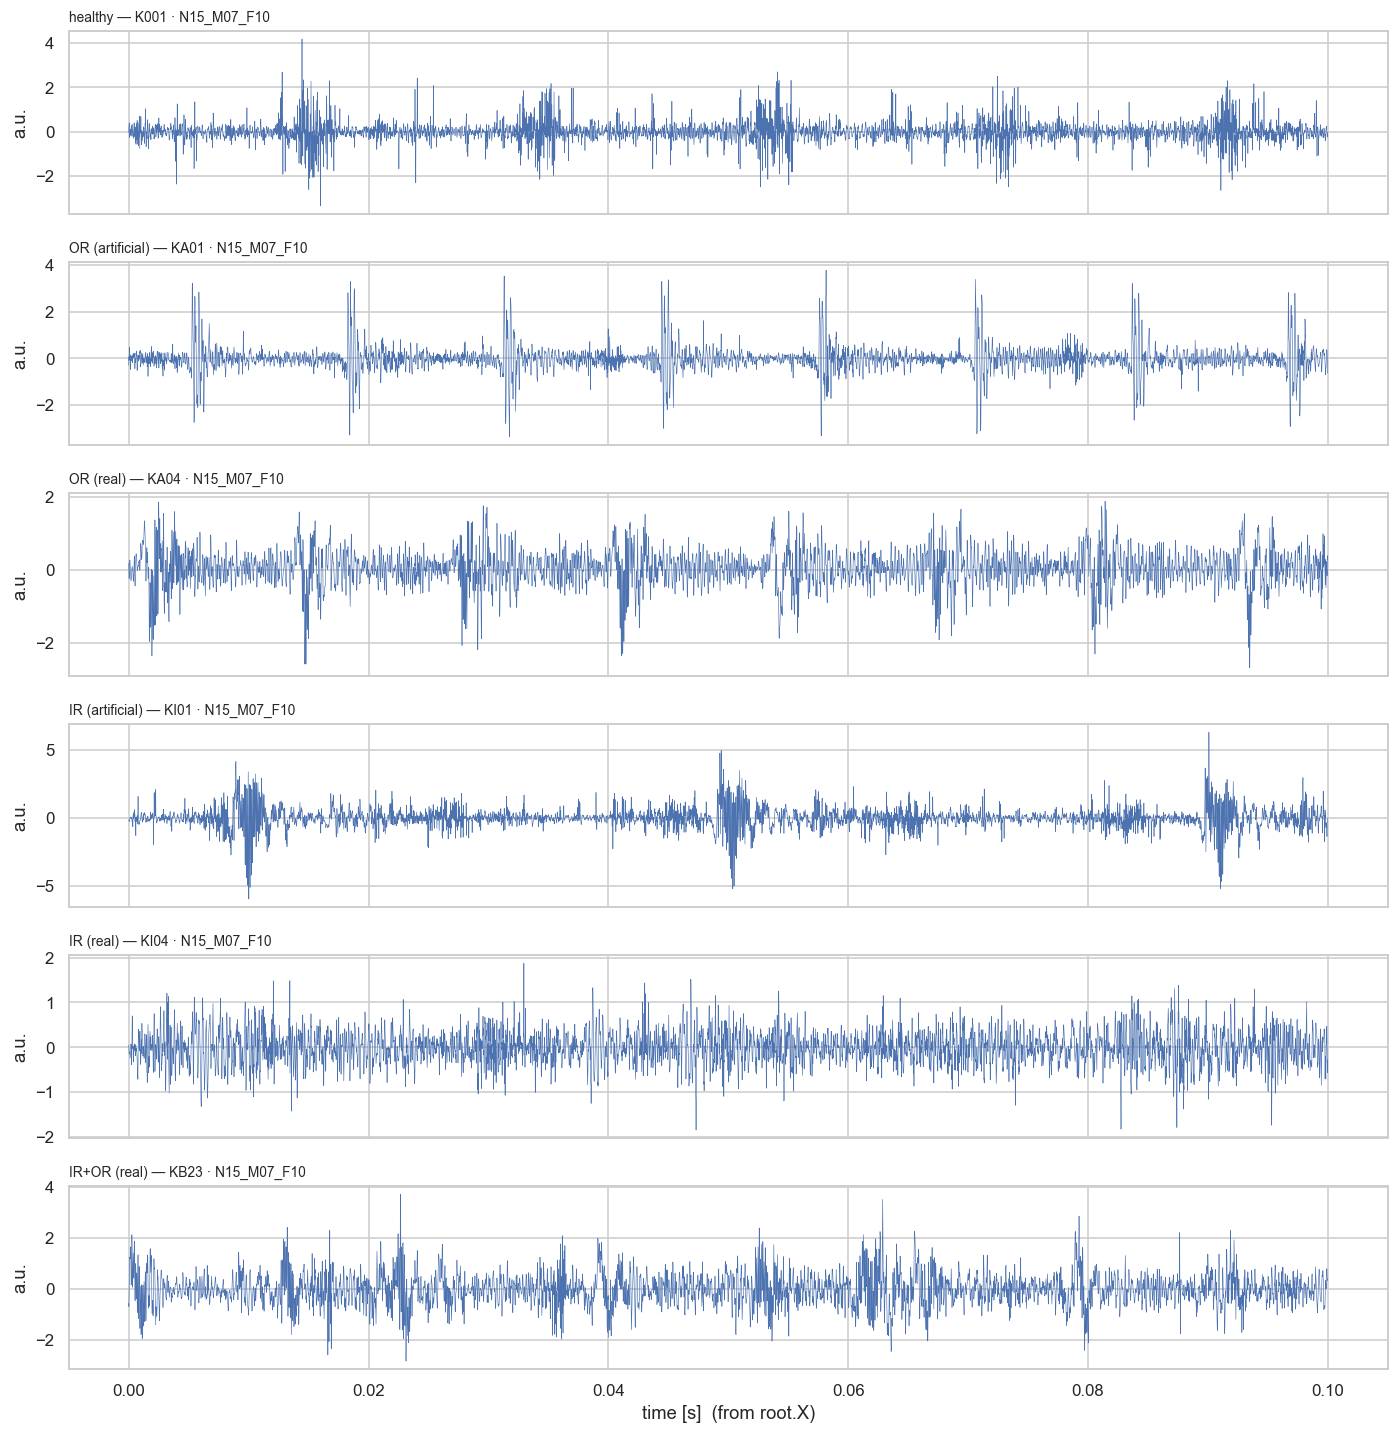

In [14]:
# Cell 8 — Waveforms (time axis from the file)


fig, ax = plt.subplots(len(picks_df), 1, figsize=(13, 2.2*len(picks_df)), sharex=True)
ax = np.atleast_1d(ax)
for a, r in zip(ax, picks_df.itertuples()):
    got = try_read(r.path, channels=["vibration_1"], with_time=True)
    if got is None: a.axis("off"); continue
    sig, tim = got
    x = sig["vibration_1"][:int(0.1*FS_FAST)]              # first 100 ms
    t = tim.get("vibration_1", np.empty(0))[:x.size]
    if t.size == x.size:
        a.plot(t, x, lw=.4); xlab = "time [s]  (from root.X)"
    else:
        a.plot(np.arange(x.size), x, lw=.4); xlab = "sample index  (no X axis in file)"
    a.set_title(f"{r.title} — {r.bearing} · {r.cond}", loc="left", fontsize=9)
    a.set_ylabel("a.u.")
ax[-1].set_xlabel(xlab)
fig.tight_layout(); fig.savefig(FIG/"waveforms.png", dpi=120); plt.show()

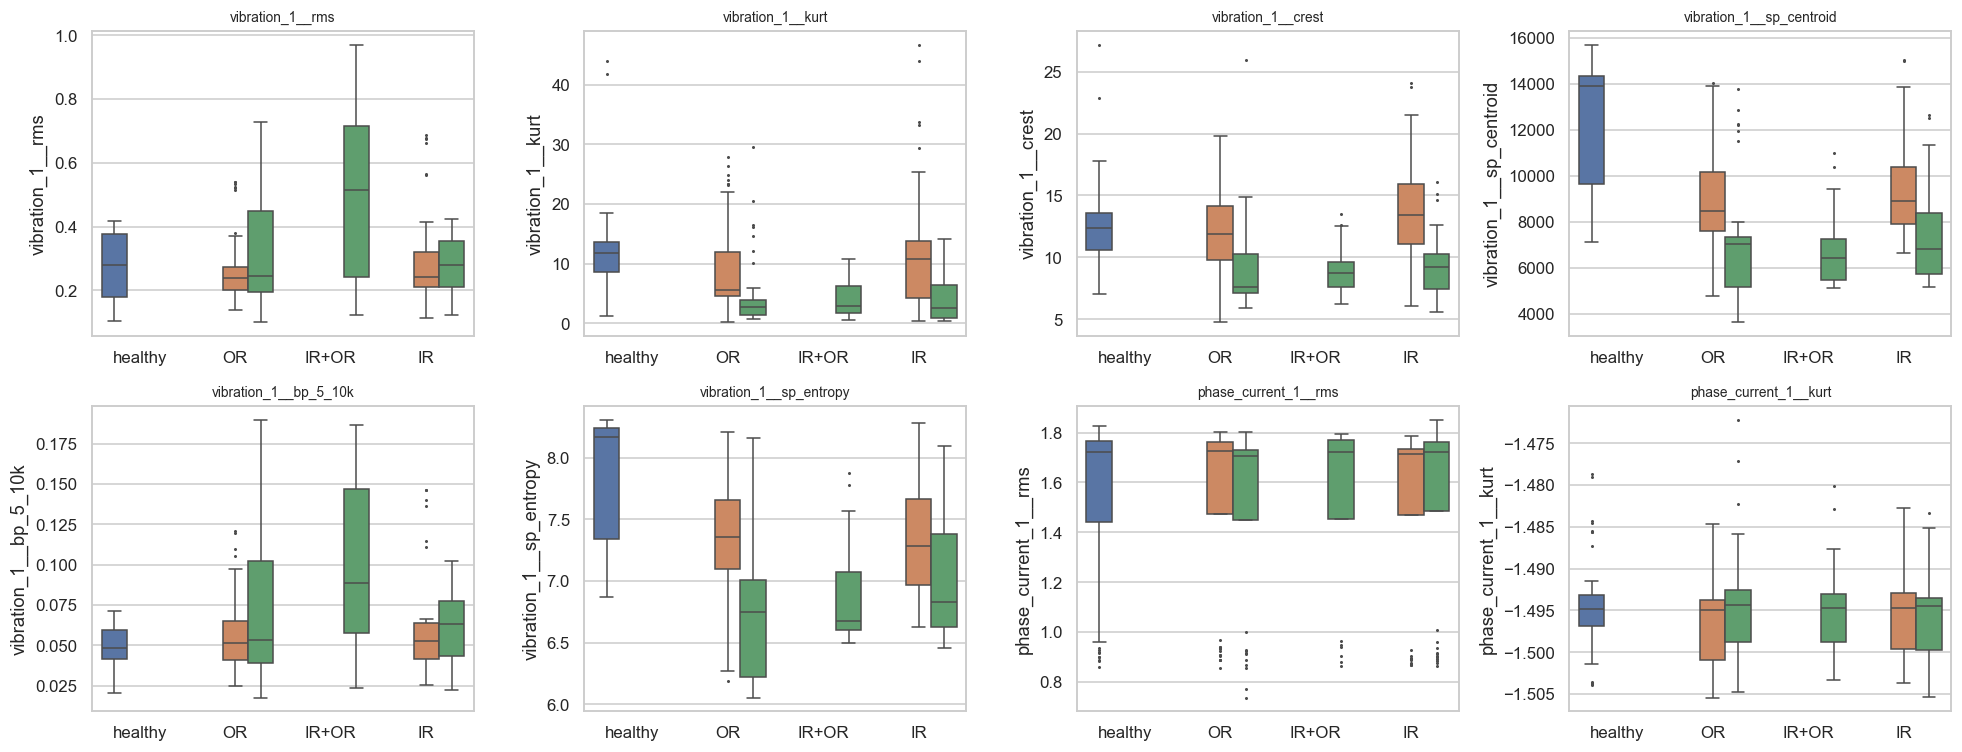

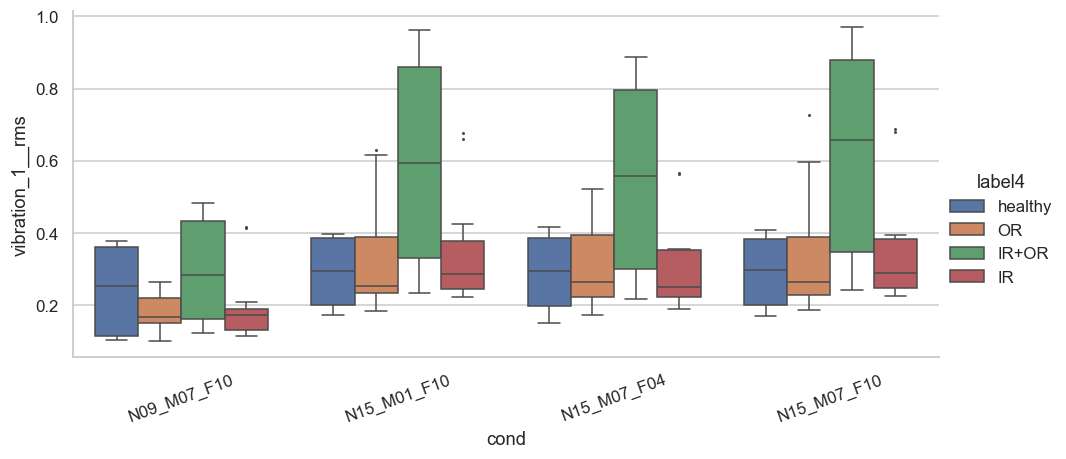

In [15]:
# Cell 9 — Feature distributions by class & operating point


fcols = [c for c in ["vibration_1__rms","vibration_1__kurt","vibration_1__crest",
                     "vibration_1__sp_centroid","vibration_1__bp_5_10k",
                     "vibration_1__sp_entropy","phase_current_1__rms",
                     "phase_current_1__kurt"] if c in feat.columns]
fig, ax = plt.subplots(2, 4, figsize=(18, 7))
for a, c in zip(ax.ravel(), fcols):
    sns.boxplot(data=feat, x=LABEL, y=c, hue="origin", ax=a, fliersize=1)
    a.set_title(c, fontsize=9); a.set_xlabel("")
    if a.get_legend(): a.get_legend().remove()
for a in ax.ravel()[len(fcols):]: a.axis("off")
fig.tight_layout(); fig.savefig(FIG/"feature_dists.png", dpi=120); plt.show()

g = sns.catplot(data=feat, x="cond", y="vibration_1__rms", hue=LABEL, kind="box",
                height=4, aspect=2.2, fliersize=1)
g.set_xticklabels(rotation=20); g.savefig(FIG/"rms_by_condition.png", dpi=120)

In [36]:
print("stat suffixes:", sorted({c.split("__", 1)[1] for c in feat.columns if "__" in c}))
print("ops-ish cols :", sorted(c for c in feat.columns
                               if c.split("__")[0] in {"speed","torque","force","temp_2_bearing_module"}))
print("CH_* globals :", {k: v for k, v in globals().items() if k.startswith("CH")})

stat suffixes: ['bp_0_1k', 'bp_10_20k', 'bp_1_5k', 'bp_20_32k', 'bp_5_10k', 'clearance', 'crest', 'impulse', 'kurt', 'mean', 'p2p', 'peak', 'rms', 'shape', 'skew', 'sp_centroid', 'sp_entropy', 'std']
ops-ish cols : ['force__mean', 'speed__mean', 'temp_2_bearing_module__mean', 'torque', 'torque__mean']
CH_* globals : {'CH_MAIN': ['vibration_1', 'phase_current_1', 'phase_current_2'], 'CH_SLOW': ['force', 'speed', 'torque'], 'CH_AUX': ['temp_2_bearing_module']}


resolved measured cols: {'speed': 'speed__mean', 'torque': 'torque__mean', 'force': 'force__mean', 'temp_2_bearing_module': 'temp_2_bearing_module__mean'}


label4,IR,IR+OR,OR,healthy,All
cond,,,,,
N09_M07_F10,22,6,24,12,64
N15_M01_F10,22,6,24,12,64
N15_M07_F04,22,6,24,12,64
N15_M07_F10,22,6,24,12,64
All,88,24,96,48,256


rpm               torque              radial_force              
              min   max nunique    min  max nunique          min   max nunique
cond                                                                          
N09_M07_F10   900   900       1    0.7  0.7       1         1000  1000       1
N15_M01_F10  1500  1500       1    0.1  0.1       1         1000  1000       1
N15_M07_F04  1500  1500       1    0.7  0.7       1          400   400       1
N15_M07_F10  1500  1500       1    0.7  0.7       1         1000  1000       1

speed__mean                         torque__mean                   force__mean                         temp_2_bearing_module__mean                    
                   mean   std      min      max         mean   std   min   max        mean    std     min      max                        mean   std    min    max
cond                                                                                                                                                              
N09_M07_F10      899.73  0.18   899.36   900.64         1.22  0.03  1.15  1.30     1034.03  41.77  914.37  1115.49                       46.84  4.57  28.66  54.83
N15_M01_F10     1499.65  0.15  1499.22  1500.16         0.62  0.03  0.50  0.71     1047.16  40.68  942.54  1109.87                       45.95  4.50  27.14  52.45
N15_M07_F04     1499.58  0.19  1498.80  1499.98         1.25  0.03  1.21  1.32      419.13  41.08  345.44   530.73                       46.85  4.88  25.85  54.40
N15_M07_F10     1499.60  0.24  1499.10  1500.95         1.26  0.02  1.22  1.33     1032.90  35.18  937.86  1113.19                       48.03  5.07  29.59  58.50

,speed_set,speed_meas,torque_set,torque_meas,force_set,force_meas
cond,,,,,,
N09_M07_F10,900,899.73,0.7,1.22,1000,1034.03
N15_M01_F10,1500,1499.65,0.1,0.62,1000,1047.16
N15_M07_F04,1500,1499.58,0.7,1.25,400,419.13
N15_M07_F10,1500,1499.60,0.7,1.26,1000,1032.90


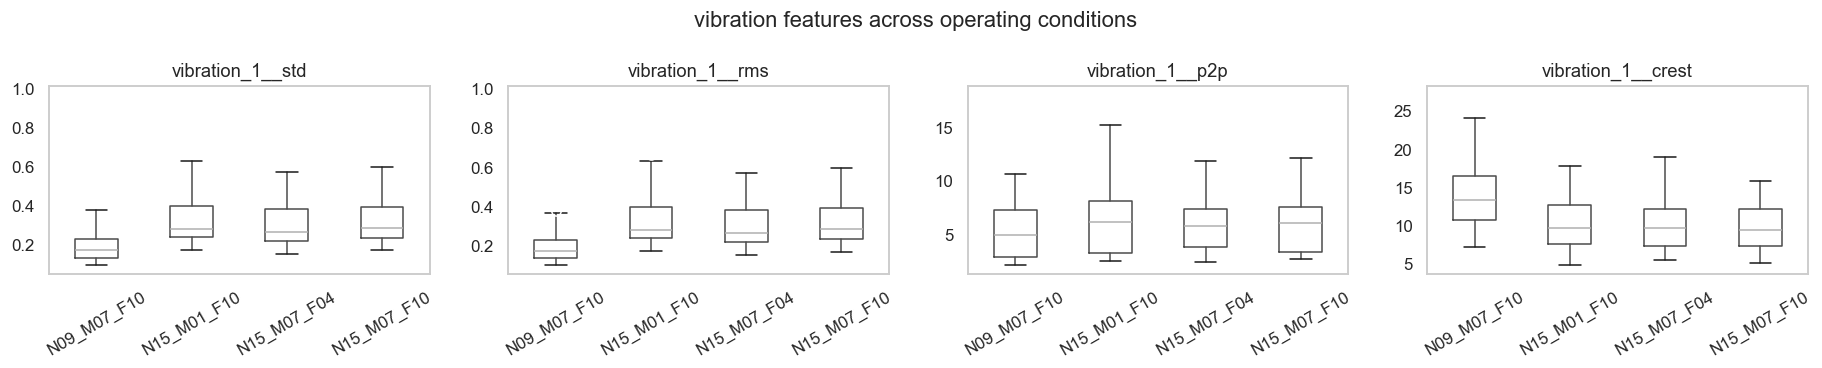

In [37]:
# Cell 9b — Operating-condition check (setpoint vs. measured)

# ---- channel groups: derive from the frame, don't assume constants ---------
OPS_CH  = ["speed", "torque", "force"]
TEMP_CH = "temp_2_bearing_module"
FAST_CH = ["vibration_1", "phase_current_1", "phase_current_2"]

def pick_stat(ch, prefer=("median", "p50", "q50", "mean", "avg")):
    """actual column name for a channel's central-tendency stat, else None"""
    for s in prefer:
        if (c := f"{ch}__{s}") in feat.columns:
            return c
    cands = sorted(c for c in feat.columns
                   if c.startswith(f"{ch}__") and not c.startswith("n_samples__"))
    return cands[0] if cands else None

MEAS = {ch: pick_stat(ch) for ch in OPS_CH + [TEMP_CH]}
MEAS = {ch: c for ch, c in MEAS.items() if c}
print("resolved measured cols:", MEAS)

SET_COLS = [c for c in ["rpm", "torque", "radial_force"] if c in feat.columns]
LABEL    = "label4"

# 1) file count per condition x damage class
display(pd.crosstab(feat["cond"], feat[LABEL], margins=True))

# 2) nominal setpoints from the filename metadata
if SET_COLS:
    display(feat.groupby("cond")[SET_COLS].agg(["min", "max", "nunique"]))

# 3) measured operating point per condition
if MEAS:
    display(feat.groupby("cond")[list(MEAS.values())]
                .agg(["mean", "std", "min", "max"]).round(2))

    # 4) setpoint vs. measurement consistency
    pairs = [("rpm", "speed"), ("torque", "torque"), ("radial_force", "force")]
    rows = {}
    for set_col, ch in pairs:
        if set_col in feat.columns and ch in MEAS:
            g = feat.groupby("cond")
            rows[f"{ch}_set"]  = g[set_col].first()
            rows[f"{ch}_meas"] = g[MEAS[ch]].mean()
    if rows:
        display(pd.DataFrame(rows).round(2))

# 5) do the operating conditions dominate the vibration features?
KEY = [c for c in feat.columns
       if c.startswith("vibration_1__")
       and c.split("__")[1] in {"rms", "kurtosis", "crest", "p2p", "std"}][:4]
if KEY:
    fig, axes = plt.subplots(1, len(KEY), figsize=(4.2 * len(KEY), 3.4))
    for ax, c in zip(np.atleast_1d(axes), KEY):
        feat.boxplot(column=c, by="cond", ax=ax, grid=False, rot=30)
        ax.set_title(c); ax.set_xlabel("")
    plt.suptitle("vibration features across operating conditions")
    plt.tight_layout(); plt.savefig(OUT / "09b_features_by_condition.png", dpi=140); plt.show()

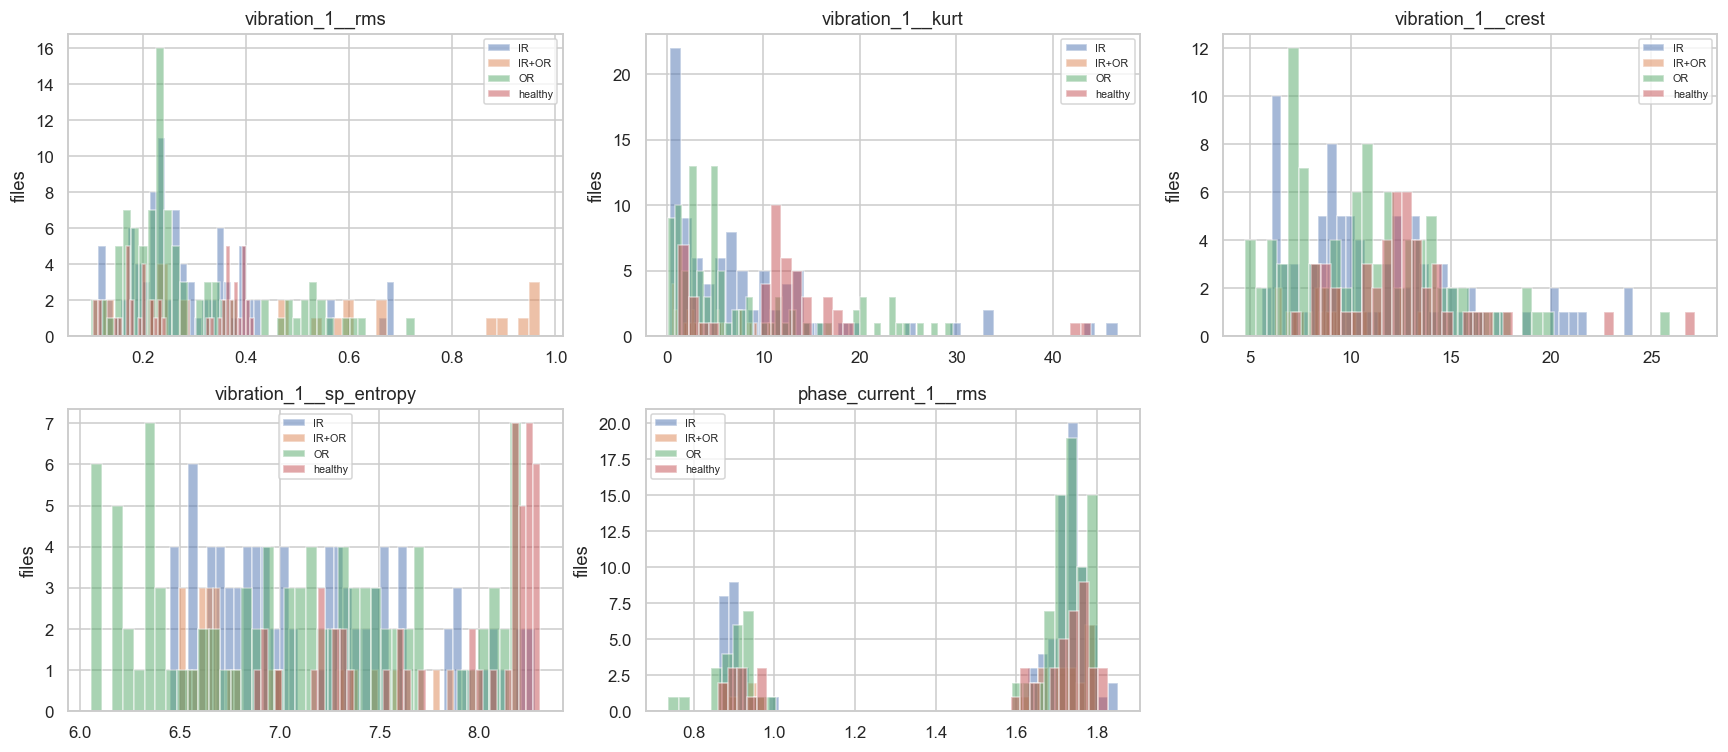

In [21]:
# Cell 9c — Class histograms



hcols = [c for c in ["vibration_1__rms","vibration_1__kurt","vibration_1__crest",
                     "vibration_1__sp_entropy","vibration_1__be_1_5k",
                     "phase_current_1__rms"] if c in feat.columns]
fig, ax = plt.subplots(2, 3, figsize=(16, 7))
for a, c in zip(ax.ravel(), hcols):
    for g_, d in feat.groupby(LABEL):
        a.hist(d[c].dropna(), bins=40, alpha=.5, label=g_)
    a.set(title=c, ylabel="files"); a.legend(fontsize=7)
for a in ax.ravel()[len(hcols):]: a.axis("off")
fig.tight_layout(); fig.savefig(FIG/"feature_hists.png", dpi=120); plt.show()

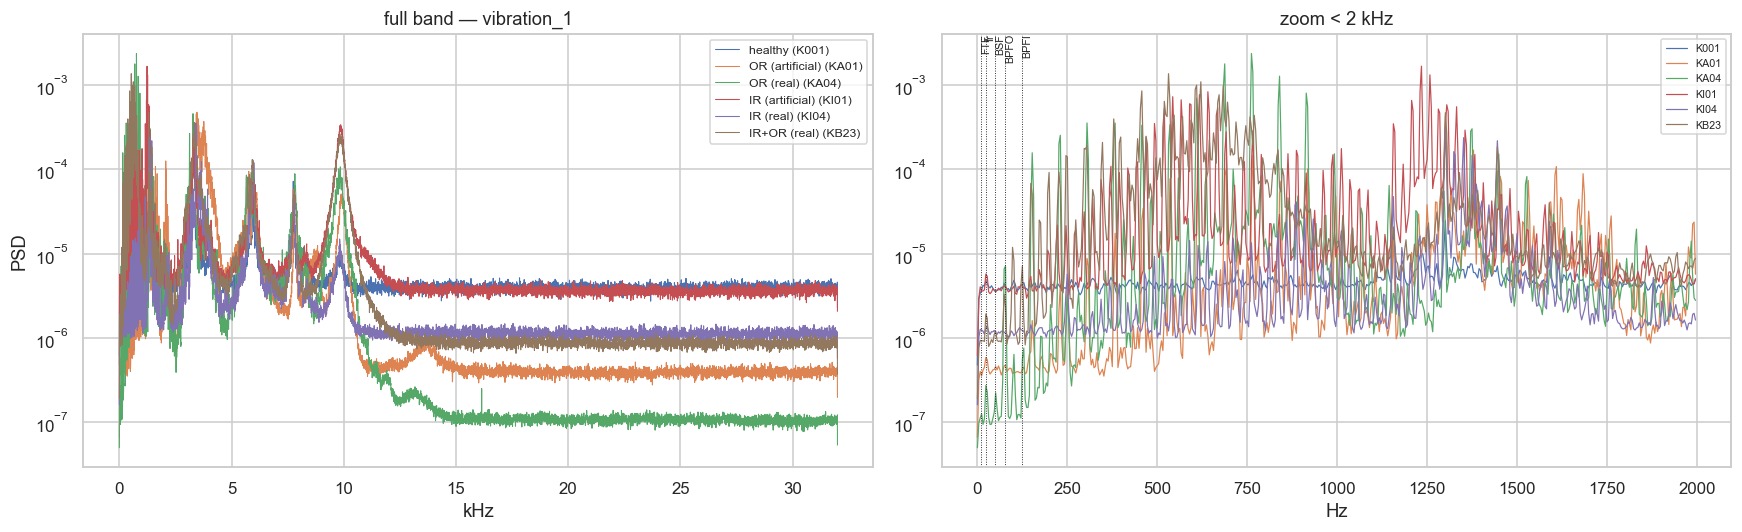

In [22]:
#Cell 10 — Class-averaged spectra + fault frequencies


def mean_psd(bearing, cond="N15_M07_F10", ch="vibration_1", k=5, nperseg=16384):
    ps, f = [], None
    for _, r in files.query("bearing==@bearing and cond==@cond").head(k).iterrows():
        d = try_read(r.path, channels=[ch], n_keep=N_KEEP)
        if d is None or ch not in d: continue
        f, P = signal.welch(d[ch], fs=FS_FAST, nperseg=nperseg)
        ps.append(P)
    return (f, np.mean(ps, 0)) if ps else (None, None)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for r in picks_df.itertuples():
    f, P = mean_psd(r.bearing)
    if f is None: continue
    ax[0].semilogy(f/1000, P, lw=.7, label=f"{r.title} ({r.bearing})")
    m = f < 2000
    ax[1].semilogy(f[m], P[m], lw=.8, label=r.bearing)
ax[0].set(xlabel="kHz", ylabel="PSD", title="full band — vibration_1")
ax[1].set(xlabel="Hz", title="zoom < 2 kHz")
ff = fault_freqs(1500)                    # picks are all at N15
for k, v in ff.items():
    ax[1].axvline(v, color="k", ls=":", lw=.6)
    ax[1].text(v, ax[1].get_ylim()[1], k, fontsize=7, rotation=90, va="top")
ax[0].legend(fontsize=8); ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG/"psd.png", dpi=120); plt.show()

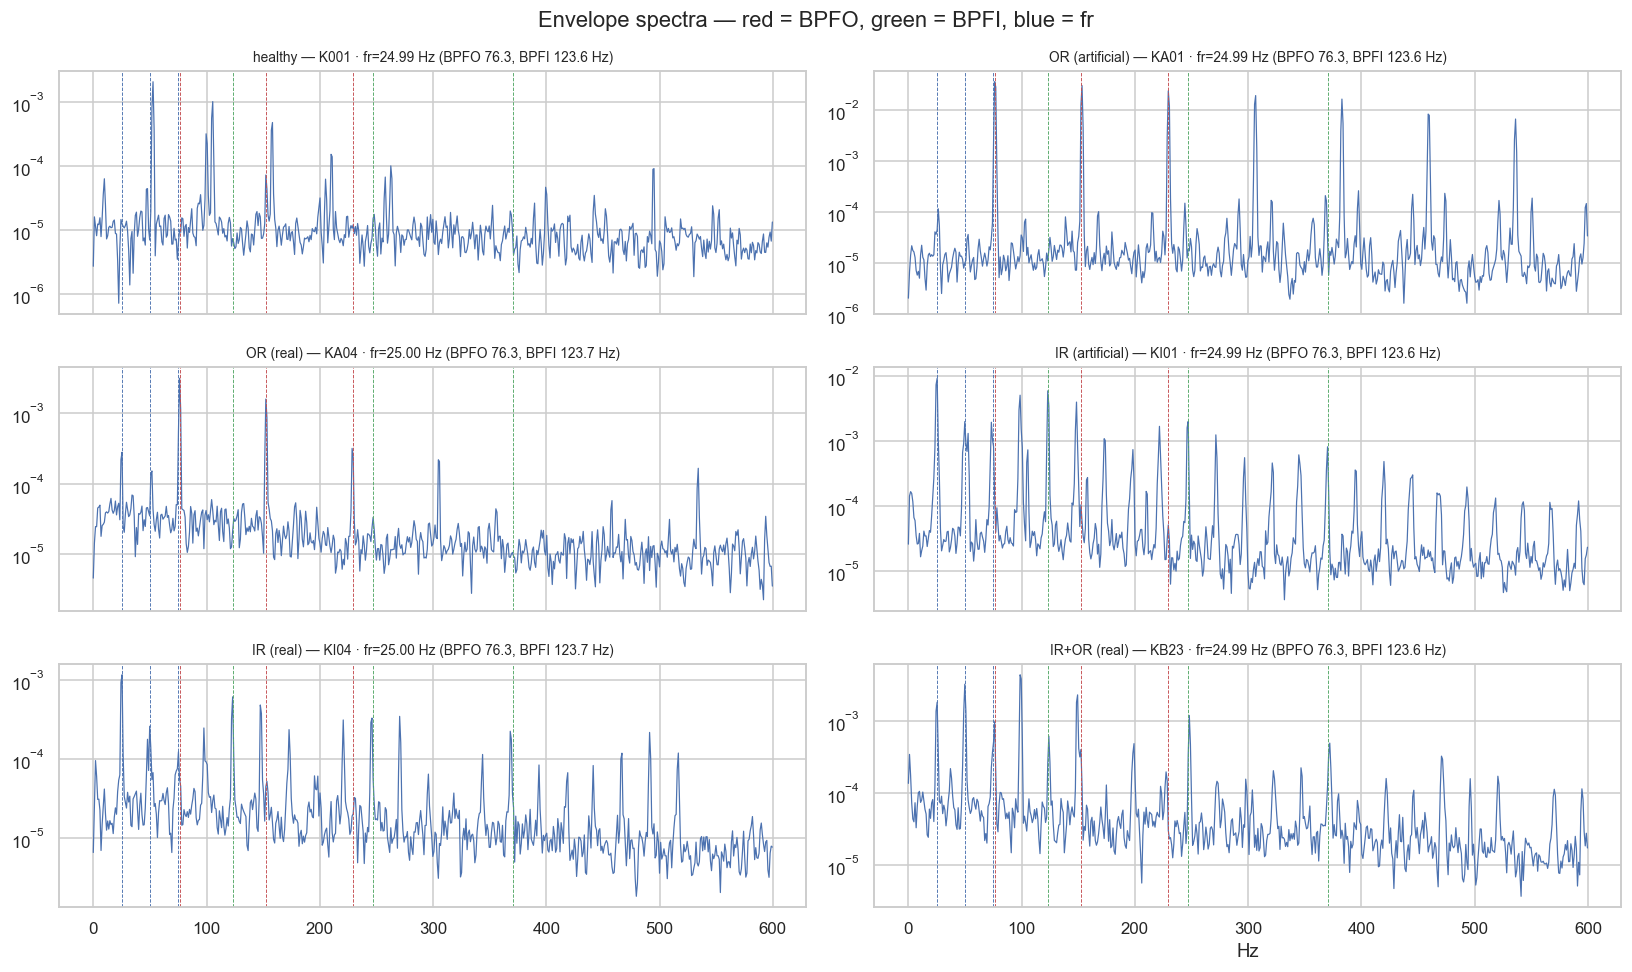

In [23]:
# Cell 11 — Envelope spectra (markers follow each file's own rpm)



def envelope_spectrum(x, fs=FS_FAST, band=(2000, 10000), fmax=600):
    sos = signal.butter(4, band, btype="bandpass", fs=fs, output="sos")
    env = np.abs(signal.hilbert(signal.sosfiltfilt(sos, x)))
    env -= env.mean()
    f, P = signal.welch(env, fs=fs, nperseg=min(2**16, env.size))
    m = f <= fmax
    return f[m], P[m]

fig, ax = plt.subplots(3, 2, figsize=(15, 9), sharex=True)
for a, r in zip(ax.ravel(), picks_df.itertuples()):
    d = try_read(r.path, channels=["vibration_1", "speed"], n_keep=N_KEEP)
    if d is None or "vibration_1" not in d: a.axis("off"); continue
    rpm_meas = float(np.median(d["speed"])) if "speed" in d and d["speed"].size else r.rpm
    ffr = fault_freqs(rpm_meas)                       # per-file, not hard-coded 1500
    f, P = envelope_spectrum(d["vibration_1"])
    a.plot(f, P, lw=.8); a.set_yscale("log")
    a.set_title(f"{r.title} — {r.bearing} · fr={ffr['fr']:.2f} Hz "
                f"(BPFO {ffr['BPFO']:.1f}, BPFI {ffr['BPFI']:.1f} Hz)", fontsize=9)
    for k, c in zip(("BPFO","BPFI","fr"), ("r","g","b")):
        for h in (1, 2, 3):
            a.axvline(ffr[k]*h, color=c, ls="--", lw=.6)
for a in ax.ravel()[len(picks_df):]: a.axis("off")
ax.ravel()[-1].set_xlabel("Hz" if ax.ravel()[-1].axison else "")
fig.suptitle("Envelope spectra — red = BPFO, green = BPFI, blue = fr")
fig.tight_layout(); fig.savefig(FIG/"envelope_spectra.png", dpi=120); plt.show()

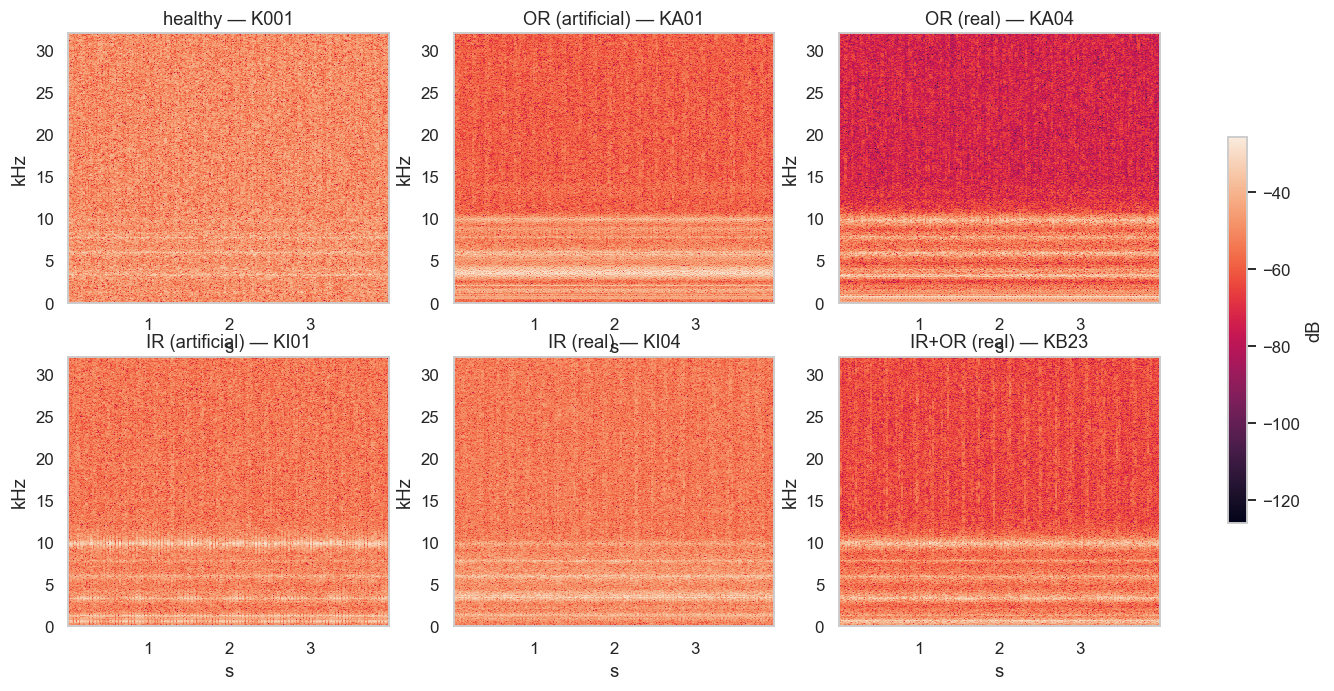

In [24]:
#Cell 11b — Spectrogram grid (all classes)


fig, ax = plt.subplots(2, 3, figsize=(16, 7)); im = None
for a, r in zip(ax.ravel(), picks_df.itertuples()):
    d = try_read(r.path, channels=["vibration_1"], n_keep=N_KEEP)
    if d is None or "vibration_1" not in d: a.axis("off"); continue
    f, t, S = signal.spectrogram(d["vibration_1"], fs=FS_FAST, nperseg=2048, noverlap=1536)
    im = a.pcolormesh(t, f/1000, 10*np.log10(S + 1e-20), shading="auto")
    a.set(title=f"{r.title} — {r.bearing}", xlabel="s", ylabel="kHz"); a.grid(False)
for a in ax.ravel()[len(picks_df):]: a.axis("off")
if im is not None:
    fig.colorbar(im, ax=ax.ravel().tolist(), shrink=.65, label="dB")
fig.savefig(FIG/"spectrograms.png", dpi=120); plt.show()

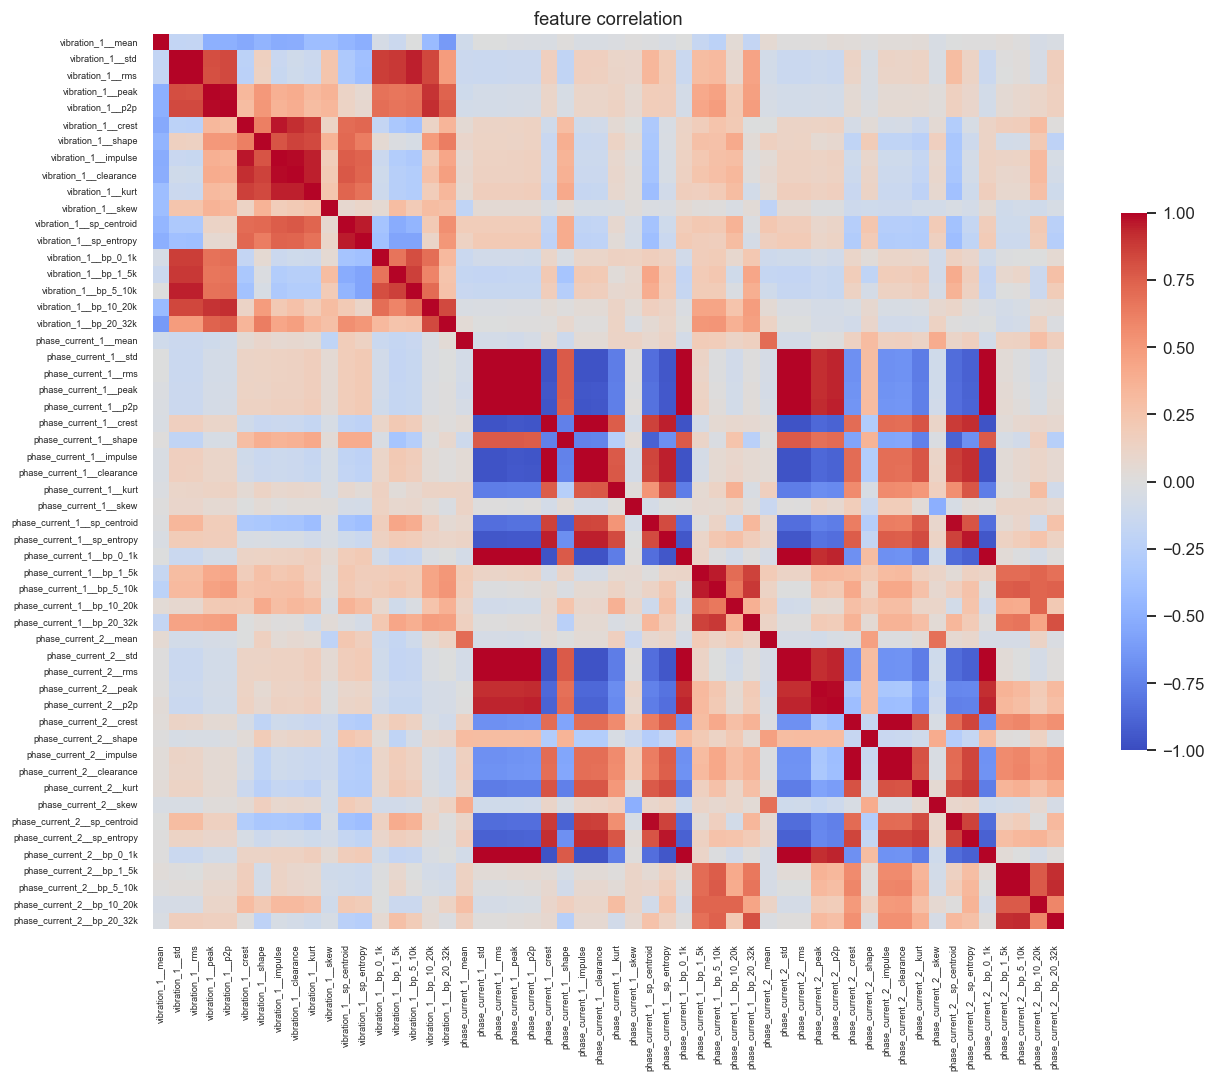

|r| > 0.95 — candidates for removal:


,,r
phase_current_1__std,phase_current_1__bp_0_1k,0.999999
phase_current_2__std,phase_current_2__bp_0_1k,0.999999
phase_current_1__std,phase_current_1__rms,0.999999
phase_current_1__rms,phase_current_1__bp_0_1k,0.999998
phase_current_2__std,phase_current_2__rms,0.999967
phase_current_2__rms,phase_current_2__bp_0_1k,0.999966
phase_current_1__bp_0_1k,phase_current_2__bp_0_1k,0.999936
phase_current_1__std,phase_current_2__bp_0_1k,0.999935
phase_current_1__rms,phase_current_2__bp_0_1k,0.999935
vibration_1__std,vibration_1__rms,0.999934


In [25]:
# Cell 12a — Correlation heatmap + redundant pairs


Fnum = feat[FEAT_COLS].dropna(axis=1, how="any").loc[:, lambda d: d.std() > 0]
C = Fnum.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(C, cmap="coolwarm", center=0, vmin=-1, vmax=1, xticklabels=True,
            yticklabels=True, cbar_kws={"shrink": .6}, ax=ax)
ax.set_title("feature correlation"); ax.tick_params(labelsize=6)
fig.tight_layout(); fig.savefig(FIG/"corr.png", dpi=120); plt.show()

u = C.where(np.triu(np.ones(C.shape), 1).astype(bool)).stack()
print("|r| > 0.95 — candidates for removal:")
display(u[u.abs() > .95].sort_values(key=abs, ascending=False).to_frame("r").head(20))

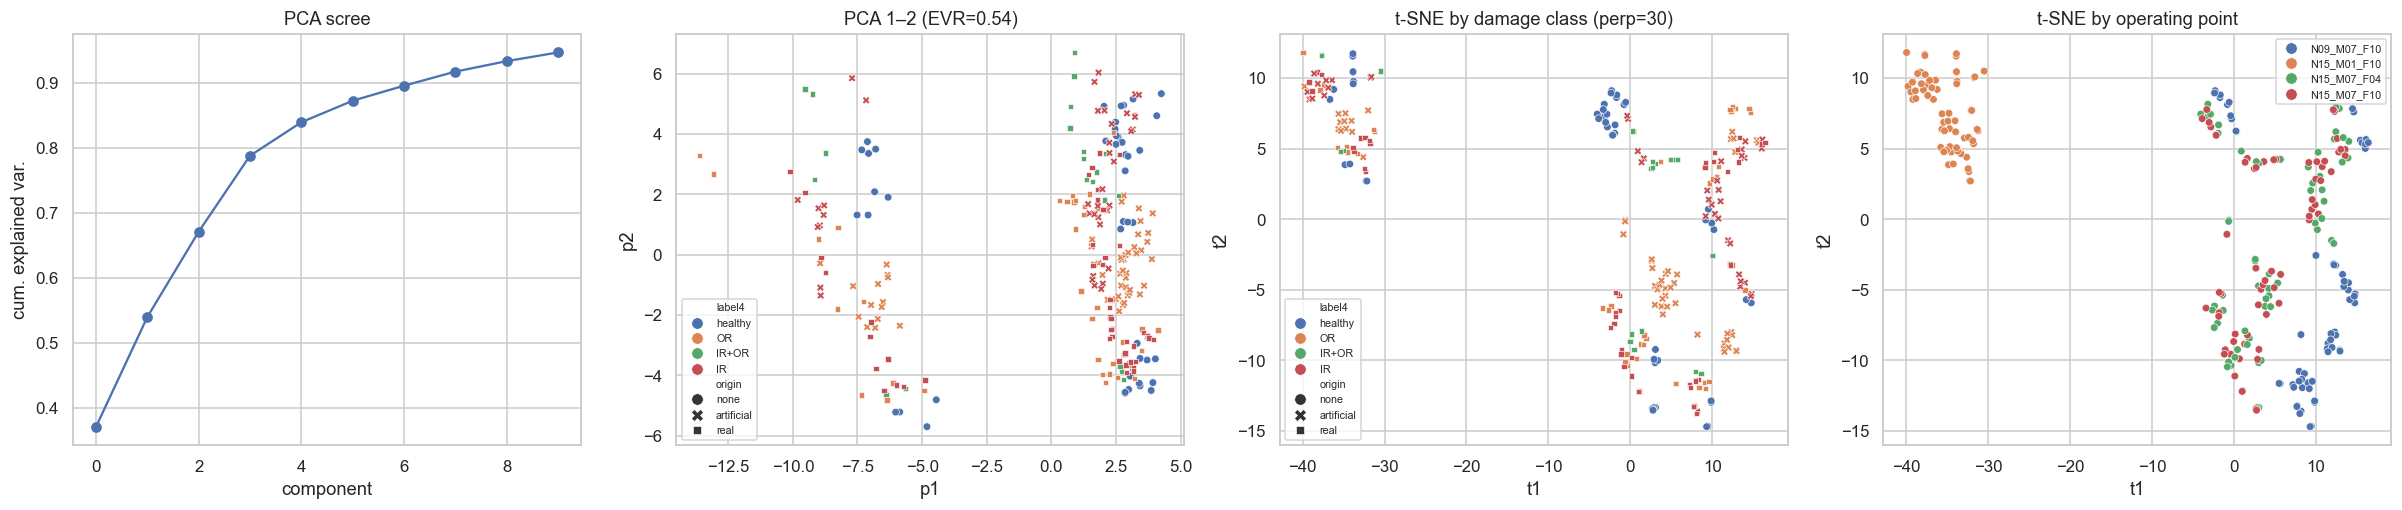

In [26]:
#Cell 12b — PCA scree + PCA + t-SNE (class and condition colouring)


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X   = StandardScaler().fit_transform(Fnum.values)
pca = PCA(n_components=min(10, X.shape[1])).fit(X); Z = pca.transform(X)
perp = min(30, max(5, (len(X) - 1) // 3))
ts   = TSNE(n_components=2, perplexity=perp, init="pca", random_state=SEED).fit_transform(Z)

E = feat.loc[Fnum.index].assign(p1=Z[:,0], p2=Z[:,1], t1=ts[:,0], t2=ts[:,1])

fig, ax = plt.subplots(1, 4, figsize=(22, 4.8))
ax[0].plot(np.cumsum(pca.explained_variance_ratio_), "o-")
ax[0].set(xlabel="component", ylabel="cum. explained var.", title="PCA scree")
sns.scatterplot(data=E, x="p1", y="p2", hue=LABEL, style="origin", s=25, ax=ax[1])
ax[1].set(title=f"PCA 1–2 (EVR={pca.explained_variance_ratio_[:2].sum():.2f})")
sns.scatterplot(data=E, x="t1", y="t2", hue=LABEL, style="origin", s=25, ax=ax[2])
ax[2].set(title=f"t-SNE by damage class (perp={perp})")
sns.scatterplot(data=E, x="t1", y="t2", hue="cond", s=25, ax=ax[3])
ax[3].set(title="t-SNE by operating point")
for a in ax[1:]: a.legend(fontsize=7, markerscale=1.5)
fig.tight_layout(); fig.savefig(FIG/"pca_tsne.png", dpi=120); plt.show()

In [28]:
# Cell 13 — Split strategies (leakage-aware)



# Rule: files/windows of the SAME bearing must never appear in train and test.
ARTIFICIAL = [b for b, (c, o, *_) in DAMAGE_CATALOG.items() if o == "artificial"]
REAL       = [b for b, (c, o, *_) in DAMAGE_CATALOG.items() if o == "real"]
HEALTHY    = [b for b, (c, o, *_) in DAMAGE_CATALOG.items() if c == "healthy"]

splits = {
 "artificial_to_real":   {"train": ARTIFICIAL + HEALTHY[:4], "test": REAL + HEALTHY[4:]},
 "real_bearing_holdout": {"train": [b for b in REAL if b not in ("KA16","KI16","KB24")] + HEALTHY[:4],
                          "test":  ["KA16","KI16","KB24"] + HEALTHY[4:]},
 "cross_condition":      {"train_cond": ["N15_M07_F10"],
                          "test_cond":  ["N09_M07_F10","N15_M01_F10","N15_M07_F04"]},
}
json.dump(splits, open(OUT/"splits.json", "w"), indent=2)

for k, v in splits.items():
    print(k, {kk: len(vv) for kk, vv in v.items()})
    if "train" in v:
        ov = set(v["train"]) & set(v["test"])
        cov = set(v["train"]) | set(v["test"])
        print("   bearing overlap:", ov or "none",
              "| bearings not covered:", sorted(set(DAMAGE_CATALOG) - cov) or "none")
        for part in ("train", "test"):
            print(f"   {part} classes:",
                  files[files.bearing.isin(v[part])][LABEL].value_counts().to_dict())

artificial_to_real {'train': 16, 'test': 16}
   bearing overlap: none | bearings not covered: none
   train classes: {'OR': 560, 'IR': 400, 'healthy': 320}
   test classes: {'IR': 480, 'OR': 400, 'IR+OR': 240, 'healthy': 160}
real_bearing_holdout {'train': 15, 'test': 5}
   bearing overlap: none | bearings not covered: ['KA01', 'KA03', 'KA05', 'KA06', 'KA07', 'KA08', 'KA09', 'KI01', 'KI03', 'KI05', 'KI07', 'KI08']
   train classes: {'IR': 400, 'healthy': 320, 'OR': 320, 'IR+OR': 160}
   test classes: {'healthy': 160, 'OR': 80, 'IR+OR': 80, 'IR': 80}
cross_condition {'train_cond': 1, 'test_cond': 3}


In [31]:
# Cell 14 — Persist reader + summary for notebook 2



json.dump({"n_keep": N_KEEP, "fast_channels": CH_MAIN, "slow_channels": CH_SLOW,
           "aux_channels": CH_AUX, "fs_fast": FS_FAST, "fs_slow": FS_SLOW,
           "n_files_total": int(len(files)), "n_files_featured": int(len(feat)),
           "feature_cols": FEAT_COLS, "measured_cols": MEAS_COLS, "label_col": LABEL,
           "group_col": GROUP, "seed": SEED},
          open(OUT/"eda_summary.json", "w"), indent=2)
print("wrote", OUT/"eda_summary.json")



wrote ..\data_paderborn\eda_out\eda_summary.json


In [38]:
%%writefile pdb_io.py
"""Robust Paderborn .mat reader (shared by the EDA and export notebooks)."""
import numpy as np, scipy.io as sio

FAST_CHANNELS = ["vibration_1", "phase_current_1", "phase_current_2"]
SLOW_CHANNELS = ["force", "speed", "torque"]
AUX_CHANNELS  = ["temp_2_bearing_module"]
ALL_CHANNELS  = FAST_CHANNELS + SLOW_CHANNELS + AUX_CHANNELS


def _name_of(obj):
    v = np.asarray(getattr(obj, "Name", ""))
    return str(v.ravel()[0]).strip() if v.size else ""


def _collect(obj, out):
    """Recursively pull {Name: Data}; structs with an empty Name are the X axes -> skip."""
    if hasattr(obj, "_fieldnames"):
        fn = obj._fieldnames
        if "Name" in fn:
            name = _name_of(obj)
            if not name:
                return
            data = next((getattr(obj, c) for c in ("Data", "Raw", "data", "raw") if c in fn), None)
            if data is None:
                cand = [(np.size(getattr(obj, f)), f) for f in fn
                        if np.asarray(getattr(obj, f)).dtype.kind in "fiu"]
                data = getattr(obj, max(cand)[1]) if cand else None
            if data is not None and np.size(data):
                out[name] = np.asarray(data, dtype=np.float32).ravel()
            return
        for f in fn:
            _collect(getattr(obj, f), out)
    elif isinstance(obj, np.ndarray) and obj.dtype == object:
        for it in obj.ravel():
            _collect(it, out)


def read_pdb_mat(path, channels=None, n_keep=None):
    out = {}
    try:
        mat = sio.loadmat(path, struct_as_record=False, squeeze_me=True)
        for k, v in mat.items():
            if not k.startswith("__"):
                _collect(v, out)
    except NotImplementedError:                       # MAT v7.3
        import mat73
        raw = mat73.loadmat(path)
        root = next(v for k, v in raw.items() if not k.startswith("__"))
        for s in np.atleast_1d(root["Y"]):
            nm = str(s.get("Name", "") or "").strip()
            if nm and np.size(s.get("Data", [])):
                out[nm] = np.asarray(s["Data"], dtype=np.float32).ravel()
    if channels is not None:
        out = {k: v for k, v in out.items() if k in channels}
    if n_keep is not None:
        out = {k: v[:n_keep] for k, v in out.items()}
    return out


def read_pdb_time(path, channels=None, n_keep=None):
    """Signals via the robust collector; time axes verbatim from root.X via XIndex."""
    sig, tim = read_pdb_mat(path, channels, n_keep), {}
    try:
        mat = sio.loadmat(path, struct_as_record=False, squeeze_me=True)
        root = next(v for k, v in mat.items() if not k.startswith("__"))
        axes = np.atleast_1d(getattr(root, "X", []))
        for e in np.atleast_1d(getattr(root, "Y", [])):
            nm = _name_of(e)
            if nm not in sig:
                continue
            k = int(np.ravel(getattr(e, "XIndex", 0))[0])
            if 1 <= k <= axes.size:
                t = np.asarray(getattr(axes[k - 1], "Data", []), dtype=np.float64).ravel()
                if t.size:
                    tim[nm] = t[:sig[nm].size]
    except Exception:
        pass
    return sig, tim


def safe_read(path, channels=None, n_keep=None):
    """(signals, error_string) — never raises."""
    try:
        return read_pdb_mat(path, channels, n_keep), ""
    except Exception as e:
        return {}, f"{type(e).__name__}: {e}"

Overwriting pdb_io.py
